# Diagnosis Penyakit Berdasarkan Gejala Multi Layer Perceptron + Backpropagation + Severity Weighting


| Nama | NIM |
|------|-----|
| Kevin Febrian Widhiarta | 24031554025 |
| Muhammad Tyas Subianto | 24031554077 |
| Bima Sena | 24031554214 |
| Daris Ikhwana Khoir Suhaya | 24031554215 |


 Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

dataset_name = "itachi9604/disease-symptom-description-dataset"
df_disease = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    dataset_name,
    "dataset.csv"
)

df_severity = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    dataset_name,
    "Symptom-severity.csv"
)

print("dataset.csv")
print(f"Shape: {df_disease.shape}")
print(df_disease.head(3))

print("\n Symptom-severity.csv ")
print(f"Shape: {df_severity.shape}")
print(df_severity.head(5))

100%|██████████| 617k/617k [00:01<00:00, 534kB/s]


Using Colab cache for faster access to the 'disease-symptom-description-dataset' dataset.
dataset.csv
Shape: (4920, 18)
            Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   

              Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0   dischromic _patches       NaN       NaN       NaN       NaN       NaN   
1                   NaN       NaN       NaN       NaN       NaN       NaN   
2                   NaN       NaN       NaN       NaN       NaN       NaN   

  Symptom_10 Symptom_11 Symptom_12 Symptom_13 Symptom_14 Symptom_15  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   
2        NaN        NaN        Na

#Load Dataset

Dataset dari Kaggle: **Disease-Symptom Description Dataset**
- dataset.csv mapping gejala ke penyakit
- symptom_severity.csv bobot severity tiap gejala


In [ ]:
# Info dasar dataset
print("Info Dataset ")
print(df_disease.info())
print(f"\nJumlah kelas penyakit unik: {df_disease['Disease'].nunique()}")
print(f"\nDaftar penyakit:")
print(sorted(df_disease['Disease'].unique()))

Info Dataset 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB
None

Jumlah kelas penyakit unik: 41

# Exploratory Data Analysis (EDA)

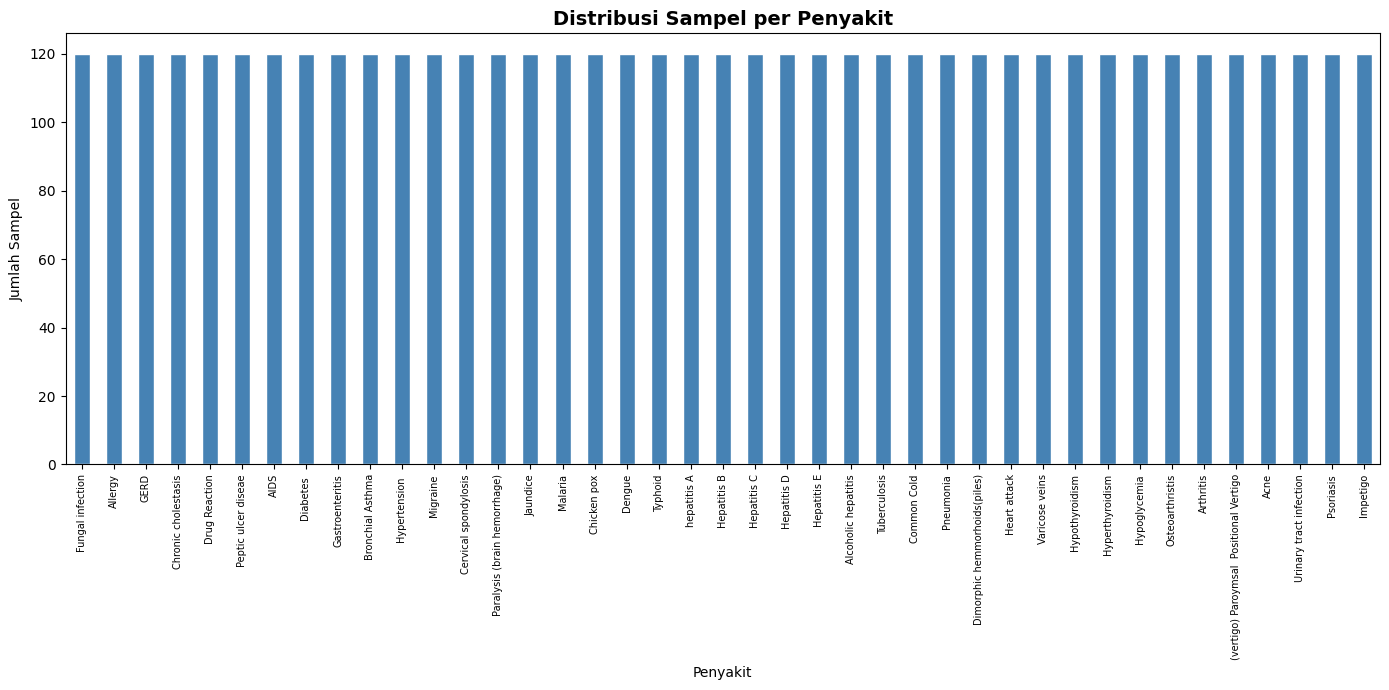


Sampel per kelas (min/max/mean): 120 / 120 / 120.0


In [ ]:
# Distribusi kelas penyakit
disease_counts = df_disease['Disease'].value_counts()

plt.figure(figsize=(14, 7))
disease_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribusi Sampel per Penyakit', fontsize=14, fontweight='bold')
plt.xlabel('Penyakit')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print(f"\nSampel per kelas (min/max/mean): {disease_counts.min()} / {disease_counts.max()} / {disease_counts.mean():.1f}")

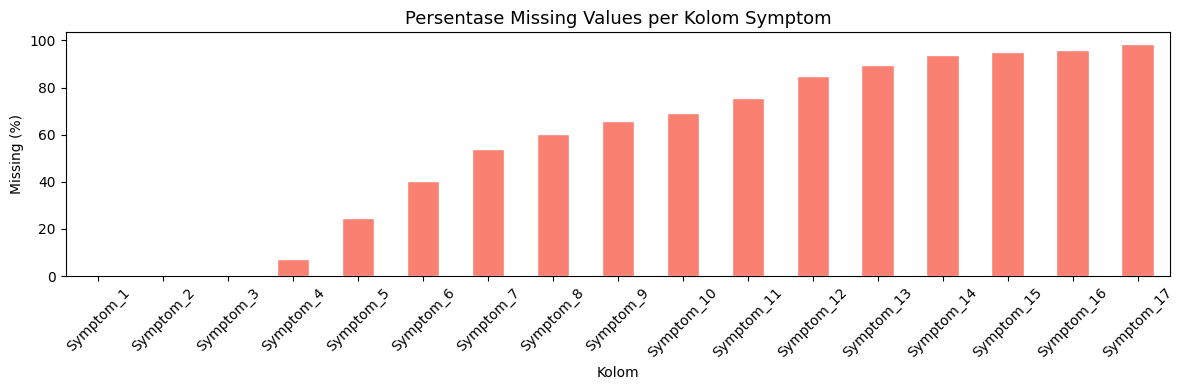

Pola missing values: semakin ke kanan semakin banyak missing wajar karena tidak semua penyakit punya 17 gejala


In [ ]:
# Cek missing values per kolom symptom
symptom_cols = [c for c in df_disease.columns if c.startswith('Symptom')]
missing_pct = df_disease[symptom_cols].isnull().mean() * 100

plt.figure(figsize=(12, 4))
missing_pct.plot(kind='bar', color='salmon', edgecolor='white')
plt.title('Persentase Missing Values per Kolom Symptom', fontsize=13)
plt.ylabel('Missing (%)')
plt.xlabel('Kolom')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Pola missing values: semakin ke kanan semakin banyak missing wajar karena tidak semua penyakit punya 17 gejala")

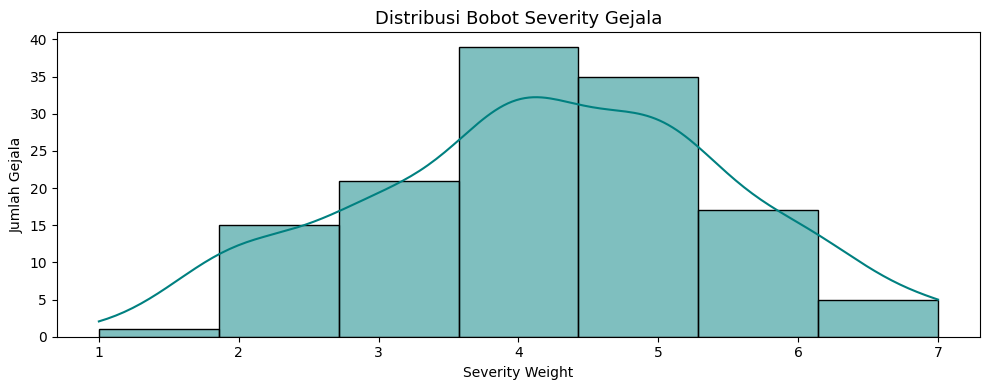

count    133.000000
mean       4.225564
std        1.323543
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        7.000000
Name: weight, dtype: float64

Gejala dengan severity tertinggi:
                Symptom  weight
                   coma       7
    swelling_of_stomach       7
             chest_pain       7
      weakness_in_limbs       7
             high_fever       7
prominent_veins_on_calf       6
  abnormal_menstruation       6
       stomach_bleeding       6
     dischromic_patches       6
     spinning_movements       6


In [ ]:
# Distribusi bobot severity
plt.figure(figsize=(10, 4))
sns.histplot(df_severity['weight'], bins=7, kde=True, color='teal')
plt.title('Distribusi Bobot Severity Gejala', fontsize=13)
plt.xlabel('Severity Weight')
plt.ylabel('Jumlah Gejala')
plt.tight_layout()
plt.show()

print(df_severity['weight'].describe())
print(f"\nGejala dengan severity tertinggi:")
print(df_severity.sort_values('weight', ascending=False).head(10).to_string(index=False))

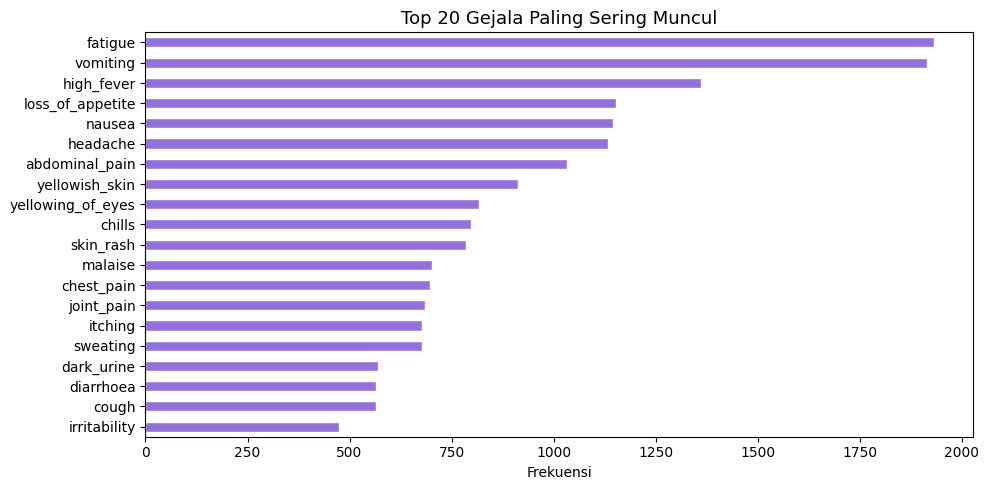

In [ ]:
# Top 20 gejala paling sering muncul di dataset
all_symptoms = []
for col in symptom_cols:
    all_symptoms.extend(df_disease[col].dropna().str.strip().tolist())

symptom_freq = pd.Series(all_symptoms).value_counts().head(20)

plt.figure(figsize=(10, 5))
symptom_freq.plot(kind='barh', color='mediumpurple', edgecolor='white')
plt.title('Top 20 Gejala Paling Sering Muncul', fontsize=13)
plt.xlabel('Frekuensi')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Step 1: Bersihkan data
df = df_disease.copy()

# Ambil kolom symptom
symptom_cols = [col for col in df.columns if col.startswith("Symptom")]

# Fungsi untuk membersihkan nama gejala
def clean_symptom_name(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    if x == "" or x == "nan":
        return np.nan

    # Ubah spasi menjadi underscore
    x = x.replace(" ", "_")

    # Hilangkan underscore ganda, contoh: dischromic__patches -> dischromic_patches
    while "__" in x:
        x = x.replace("__", "_")

    return x

# Bersihkan semua kolom symptom
for col in symptom_cols:
    df[col] = df[col].apply(clean_symptom_name)

# Bersihkan juga severity
df_severity["Symptom"] = df_severity["Symptom"].apply(clean_symptom_name)

# Buat dictionary severity
severity_dict = dict(zip(df_severity["Symptom"], df_severity["weight"]))

# Kumpulkan semua gejala unik
all_unique_symptoms = set()

for col in symptom_cols:
    all_unique_symptoms.update(df[col].dropna().unique())

# Urutkan gejala secara alfabet
all_unique_symptoms = sorted(list(all_unique_symptoms))

# Buat index untuk setiap gejala
symptom_index = {s: i for i, s in enumerate(all_unique_symptoms)}

print(f"Jumlah gejala unik: {len(all_unique_symptoms)}")
print(f"Contoh gejala: {all_unique_symptoms[:10]}")

Jumlah gejala unik: 131
Contoh gejala: ['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort']


In [ ]:
# Step 2: Multi-hot encoding
n_symptoms = len(all_unique_symptoms)
n_samples = len(df)

X_binary = np.zeros((n_samples, n_symptoms))

for i, row in df.iterrows():
    for col in symptom_cols:
        symptom = row[col]
        if pd.notna(symptom) and symptom in symptom_index:
            X_binary[i, symptom_index[symptom]] = 1

print(f"Shape X_binary: {X_binary.shape}")
print(f"Contoh baris pertama (jumlah gejala aktif): {int(X_binary[0].sum())}")

Shape X_binary: (4920, 131)
Contoh baris pertama (jumlah gejala aktif): 4


In [ ]:
# Step 3: Label encoding
le = LabelEncoder()
y = le.fit_transform(df['Disease'])

print(f"Jumlah kelas: {len(le.classes_)}")
print(f"Contoh mapping: {list(zip(le.classes_[:5], range(5)))}")

Jumlah kelas: 41
Contoh mapping: [('(vertigo) Paroymsal  Positional Vertigo', 0), ('AIDS', 1), ('Acne', 2), ('Alcoholic hepatitis', 3), ('Allergy', 4)]


#Preprocessing

Langkah-langkah:
1. Bersihkan nama gejala: strip whitespace, lowercase, dan normalisasi underscore
2. Multi-hot encoding menjadi vektor biner sejumlah gejala unik
3. Label encoding untuk kolom Disease
4. Severity weighting: kalikan vektor biner dengan bobot severity
5. Scaling global untuk weighted feature agar severity tetap berpengaruh
6. Split data menjadi train, validation, dan test:
   - Train: untuk melatih model
   - Validation: untuk early stopping dan memilih model terbaik
   - Test: hanya untuk evaluasi final

In [ ]:
# Step 4: Severity Weighting

severity_weights = np.array([
    severity_dict.get(s, 1)
    for s in all_unique_symptoms
])

X_weighted = X_binary * severity_weights

print(f"Shape X_weighted: {X_weighted.shape}")

for i in range(5):
    before_array = []
    after_array = []

    for col in symptom_cols:
        symptom = df.loc[i, col]

        if pd.notna(symptom):
            idx = symptom_index[symptom]

            before_array.append(X_binary[i, idx])
            after_array.append(X_weighted[i, idx])
        else:
            before_array.append(0.0)
            after_array.append(0.0)

    before_array = np.array(before_array)
    after_array = np.array(after_array)

    print(f"\nBaris Data ke-{i+1}")
    print(f"Sebelum weighting: {before_array}")
    print(f"Setelah weighting: {after_array}")

print(f"\nRange nilai weighted: [{X_weighted.min():.2f}, {X_weighted.max():.2f}]")

Shape X_weighted: (4920, 131)

Baris Data ke-1
Sebelum weighting: [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Setelah weighting: [1. 3. 4. 6. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Baris Data ke-2
Sebelum weighting: [1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Setelah weighting: [3. 4. 6. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Baris Data ke-3
Sebelum weighting: [1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Setelah weighting: [1. 4. 6. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Baris Data ke-4
Sebelum weighting: [1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Setelah weighting: [1. 3. 6. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Baris Data ke-5
Sebelum weighting: [1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Setelah weighting: [1. 3. 4. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Range nilai weighted: [0.00, 7.00]


In [ ]:
# Step 5: Train-Validation-Test Split + Scaling yang menjaga severity weighting

max_severity = severity_weights.max()
X_weighted_scaled = X_weighted / max_severity

# Binary data tidak perlu MinMaxScaler karena nilainya sudah 0 atau 1
X_binary_scaled = X_binary.copy()

X_temp_w, X_test_w, X_temp_b, X_test_b, y_temp, y_test = train_test_split(
    X_weighted_scaled,
    X_binary_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_w, X_val_w, X_train_b, X_val_b, y_train, y_val = train_test_split(
    X_temp_w,
    X_temp_b,
    y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print("Split data selesai.")
print(f"Train set      : {X_train_w.shape[0]} sampel")
print(f"Validation set : {X_val_w.shape[0]} sampel")
print(f"Test set       : {X_test_w.shape[0]} sampel")

print(f"\nInput features : {X_train_w.shape[1]}")
print(f"Output classes : {len(np.unique(y_train))}")

print("\nRange data weighted setelah scaling global:")
print(f"X_train_w: [{X_train_w.min():.3f}, {X_train_w.max():.3f}]")
print(f"X_val_w  : [{X_val_w.min():.3f}, {X_val_w.max():.3f}]")
print(f"X_test_w : [{X_test_w.min():.3f}, {X_test_w.max():.3f}]")

print("\nRange data binary:")
print(f"X_train_b: [{X_train_b.min():.3f}, {X_train_b.max():.3f}]")
print(f"X_val_b  : [{X_val_b.min():.3f}, {X_val_b.max():.3f}]")
print(f"X_test_b : [{X_test_b.min():.3f}, {X_test_b.max():.3f}]")

Split data selesai.
Train set      : 3148 sampel
Validation set : 788 sampel
Test set       : 984 sampel

Input features : 131
Output classes : 41

Range data weighted setelah scaling global:
X_train_w: [0.000, 1.000]
X_val_w  : [0.000, 1.000]
X_test_w : [0.000, 1.000]

Range data binary:
X_train_b: [0.000, 1.000]
X_val_b  : [0.000, 1.000]
X_test_b : [0.000, 1.000]


In [ ]:
print("Train-validation-test split sudah selesai.")
print(f"X_train_w shape: {X_train_w.shape}")
print(f"X_val_w shape  : {X_val_w.shape}")
print(f"X_test_w shape : {X_test_w.shape}")

print(f"\ny_train shape: {y_train.shape}")
print(f"y_val shape  : {y_val.shape}")
print(f"y_test shape : {y_test.shape}")

Train-validation-test split sudah selesai.
X_train_w shape: (3148, 131)
X_val_w shape  : (788, 131)
X_test_w shape : (984, 131)

y_train shape: (3148,)
y_val shape  : (788,)
y_test shape : (984,)


In [ ]:
class MLPClassifier:
    """
    Multi Layer Perceptron dari scratch.
    - Aktivasi hidden layer: ReLU / Sigmoid / Tanh
    - Aktivasi output: Softmax
    - Loss: Categorical Cross-Entropy
    - Optimizer: Mini-batch Gradient Descent
    - Regularisasi: Dropout
    """

    def __init__(self, layer_sizes, learning_rate=0.01, epochs=100,
                 batch_size=64, dropout_rate=0.0, patience=10,
                 activation='relu', verbose=True):

        self.layer_sizes = layer_sizes
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.dropout_rate = dropout_rate
        self.patience = patience
        self.activation = activation.lower()
        self.verbose = verbose

        self.weights = []
        self.biases = []
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []

        if self.activation not in ['relu', 'sigmoid', 'tanh']:
            raise ValueError("Activation harus salah satu dari: 'relu', 'sigmoid', atau 'tanh'")

        self._init_weights()

    def _init_weights(self):
        """
        Inisialisasi bobot:
        - ReLU cocok menggunakan He initialization
        - Sigmoid dan Tanh lebih cocok menggunakan Xavier initialization
        """
        for i in range(len(self.layer_sizes) - 1):
            fan_in = self.layer_sizes[i]
            fan_out = self.layer_sizes[i + 1]

            if self.activation == 'relu':
                W = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
            else:
                W = np.random.randn(fan_in, fan_out) * np.sqrt(1.0 / fan_in)

            b = np.zeros((1, fan_out))

            self.weights.append(W)
            self.biases.append(b)

    # FUNGSI AKTIVASI

    def _relu(self, Z):
        return np.maximum(0, Z)

    def _relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def _sigmoid(self, Z):
        Z = np.clip(Z, -500, 500)
        return 1 / (1 + np.exp(-Z))

    def _sigmoid_derivative(self, Z):
        s = self._sigmoid(Z)
        return s * (1 - s)

    def _tanh(self, Z):
        return np.tanh(Z)

    def _tanh_derivative(self, Z):
        return 1 - np.tanh(Z) ** 2

    def _activation_function(self, Z):
        if self.activation == 'relu':
            return self._relu(Z)
        elif self.activation == 'sigmoid':
            return self._sigmoid(Z)
        elif self.activation == 'tanh':
            return self._tanh(Z)

    def _activation_derivative(self, Z):
        if self.activation == 'relu':
            return self._relu_derivative(Z)
        elif self.activation == 'sigmoid':
            return self._sigmoid_derivative(Z)
        elif self.activation == 'tanh':
            return self._tanh_derivative(Z)

    def _softmax(self, Z):
        # Numerically stable softmax
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shifted)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    # FORWARD PROPAGATION

    def _forward(self, X, training=False):
        """
        Forward pass melalui seluruh layer.
        training=True artinya dropout diterapkan.
        """
        activations = [X]
        pre_activations = []
        dropout_masks = []

        A = X
        n_layers = len(self.weights)

        for i in range(n_layers):
            Z = A @ self.weights[i] + self.biases[i]
            pre_activations.append(Z)

            if i < n_layers - 1:
                # Hidden layer menggunakan aktivasi yang dipilih:
                # ReLU, Sigmoid, atau Tanh
                A = self._activation_function(Z)

                # Dropout hanya saat training
                if training and self.dropout_rate > 0:
                    mask = (np.random.rand(*A.shape) > self.dropout_rate) / (1 - self.dropout_rate)
                    A = A * mask
                    dropout_masks.append(mask)
                else:
                    dropout_masks.append(None)

            else:
                # Output layer tetap menggunakan Softmax
                A = self._softmax(Z)

            activations.append(A)

        return activations, pre_activations, dropout_masks

    # LOSS FUNCTION

    def _cross_entropy_loss(self, y_true, y_pred):
        """Categorical Cross-Entropy"""
        n = y_true.shape[0]

        y_oh = np.zeros_like(y_pred)
        y_oh[np.arange(n), y_true] = 1

        y_pred_clip = np.clip(y_pred, 1e-12, 1 - 1e-12)
        loss = -np.sum(y_oh * np.log(y_pred_clip)) / n

        return loss

    # BACKPROPAGATION

    def _backward(self, activations, pre_activations, dropout_masks, y_true):
      n = y_true.shape[0]
      n_layers = len(self.weights)

      y_oh = np.zeros_like(activations[-1])
      y_oh[np.arange(n), y_true] = 1

      # Gradient output layer: Softmax + Cross Entropy
      dA = activations[-1] - y_oh

      for i in reversed(range(n_layers)):
          A_prev = activations[i]

          W_current = self.weights[i].copy()

          dW = (A_prev.T @ dA) / n
          db = np.mean(dA, axis=0, keepdims=True)

          if i > 0:
              dA_prev = dA @ W_current.T
              dA_prev = dA_prev * self._activation_derivative(pre_activations[i - 1])

              if dropout_masks[i - 1] is not None:
                  dA_prev = dA_prev * dropout_masks[i - 1]

          self.weights[i] -= self.lr * dW
          self.biases[i] -= self.lr * db

          if i > 0:
              dA = dA_prev

    # TRAINING LOOP

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        n_samples = X_train.shape[0]

        best_val_loss = np.inf
        patience_counter = 0
        best_weights = None
        best_biases = None

        for epoch in range(1, self.epochs + 1):
            idx = np.random.permutation(n_samples)
            X_shuffled = X_train[idx]
            y_shuffled = y_train[idx]

            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size

                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                activations, pre_acts, masks = self._forward(X_batch, training=True)
                self._backward(activations, pre_acts, masks, y_batch)

            train_acts, _, _ = self._forward(X_train, training=False)
            train_pred = train_acts[-1]

            train_loss = self._cross_entropy_loss(y_train, train_pred)
            train_acc = accuracy_score(y_train, np.argmax(train_pred, axis=1))

            self.train_losses.append(train_loss)
            self.train_accs.append(train_acc)

            if X_val is not None:
                val_acts, _, _ = self._forward(X_val, training=False)
                val_pred = val_acts[-1]

                val_loss = self._cross_entropy_loss(y_val, val_pred)
                val_acc = accuracy_score(y_val, np.argmax(val_pred, axis=1))

                self.val_losses.append(val_loss)
                self.val_accs.append(val_acc)

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                    best_weights = [w.copy() for w in self.weights]
                    best_biases = [b.copy() for b in self.biases]
                else:
                    patience_counter += 1

                    if patience_counter >= self.patience:
                        if self.verbose:
                            print(f"Early stopping di epoch {epoch}")
                        break

                if self.verbose and epoch % 10 == 0:
                    print(
                        f"Epoch {epoch:4d} | "
                        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
                    )

            else:
                if self.verbose and epoch % 10 == 0:
                    print(
                        f"Epoch {epoch:4d} | "
                        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}"
                    )

        if best_weights is not None:
            self.weights = best_weights
            self.biases = best_biases

        return self

    # PREDIKSI

    def predict(self, X):
        activations, _, _ = self._forward(X, training=False)
        return np.argmax(activations[-1], axis=1)

    def predict_proba(self, X):
        activations, _, _ = self._forward(X, training=False)
        return activations[-1]

Implementasi MLP dari Scratch

MLP dibangun manual menggunakan NumPy, mencakup:

- **Forward propagation** menggunakan fungsi aktivasi ReLU, Sigmoid, atau Tanh pada hidden layer, dan Softmax pada output layer
- **Loss function** menggunakan Categorical Cross-Entropy
- **Backpropagation** untuk menghitung gradien dan memperbarui bobot
- Support **multiple hidden layers**
- Support perbandingan fungsi aktivasi

Eksperimen Variasi Hidden Layer


| Eksperimen | Arsitektur |
|---|---|
| A | 1 hidden layer (128) |
| B | 2 hidden layers (128, 64) |
| C | 3 hidden layers (256, 128, 64) |
| D | 4 hidden layers (512, 256, 128, 64) |

In [ ]:
# Dimensi input dan output
input_dim = X_train_w.shape[1]
output_dim = len(np.unique(y_train))
experiments = {
    'A_1layer_128':       [input_dim, 128, output_dim],
    'B_2layer_128-64':    [input_dim, 128, 64, output_dim],
    'C_3layer_256-128-64':[input_dim, 256, 128, 64, output_dim],
    'D_4layer_512-256-128-64': [input_dim, 512, 256, 128, 64, output_dim],
}

print("Konfigurasi eksperimen:")
for name, arch in experiments.items():
    print(f"  {name}: {arch}")

Konfigurasi eksperimen:
  A_1layer_128: [131, 128, 41]
  B_2layer_128-64: [131, 128, 64, 41]
  C_3layer_256-128-64: [131, 256, 128, 64, 41]
  D_4layer_512-256-128-64: [131, 512, 256, 128, 64, 41]


In [ ]:
# Eksperimen Variasi Hidden Layer
# Menggunakan data severity weighting
# Model dipilih berdasarkan validation set, bukan test set.

results = {}

for name, arch in experiments.items():
    print(f"Eksperimen Hidden Layer: {name}")
    print(f"Arsitektur: {arch}")
    print("Aktivasi: RELU")

    # Seed diulang agar perbandingan antar arsitektur lebih konsisten
    np.random.seed(42)

    mlp = MLPClassifier(
        layer_sizes=arch,
        learning_rate=0.01,
        epochs=10,
        batch_size=64,
        dropout_rate=0.3,
        patience=5,
        activation='relu',
        verbose=True
    )

    # Validation set dipakai untuk early stopping
    mlp.fit(X_train_w, y_train, X_val=X_val_w, y_val=y_val)

    # Evaluasi model pada validation set, bukan test set
    y_val_pred = mlp.predict(X_val_w)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_prec = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_rec = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

    results[name] = {
        'model': mlp,
        'val_accuracy': val_acc,
        'val_precision': val_prec,
        'val_recall': val_rec,
        'val_f1': val_f1,
        'architecture': arch
    }

    print(f"\n>> Hasil Validation {name}:")
    print(f"Val Accuracy : {val_acc:.4f}")
    print(f"Val Precision: {val_prec:.4f}")
    print(f"Val Recall   : {val_rec:.4f}")
    print(f"Val F1-Score : {val_f1:.4f}")
    print()

Eksperimen Hidden Layer: A_1layer_128
Arsitektur: [131, 128, 41]
Aktivasi: RELU
Epoch   10 | Train Loss: 3.2931 | Train Acc: 0.4949 | Val Loss: 3.2940 | Val Acc: 0.4975

>> Hasil Validation A_1layer_128:
Val Accuracy : 0.4975
Val Precision: 0.4222
Val Recall   : 0.4975
Val F1-Score : 0.4112

Eksperimen Hidden Layer: B_2layer_128-64
Arsitektur: [131, 128, 64, 41]
Aktivasi: RELU
Epoch   10 | Train Loss: 3.1448 | Train Acc: 0.4457 | Val Loss: 3.1451 | Val Acc: 0.4429

>> Hasil Validation B_2layer_128-64:
Val Accuracy : 0.4429
Val Precision: 0.3922
Val Recall   : 0.4429
Val F1-Score : 0.3603

Eksperimen Hidden Layer: C_3layer_256-128-64
Arsitektur: [131, 256, 128, 64, 41]
Aktivasi: RELU
Epoch   10 | Train Loss: 2.9124 | Train Acc: 0.6017 | Val Loss: 2.9147 | Val Acc: 0.6091

>> Hasil Validation C_3layer_256-128-64:
Val Accuracy : 0.6091
Val Precision: 0.4992
Val Recall   : 0.6091
Val F1-Score : 0.5228

Eksperimen Hidden Layer: D_4layer_512-256-128-64
Arsitektur: [131, 512, 256, 128, 64, 41

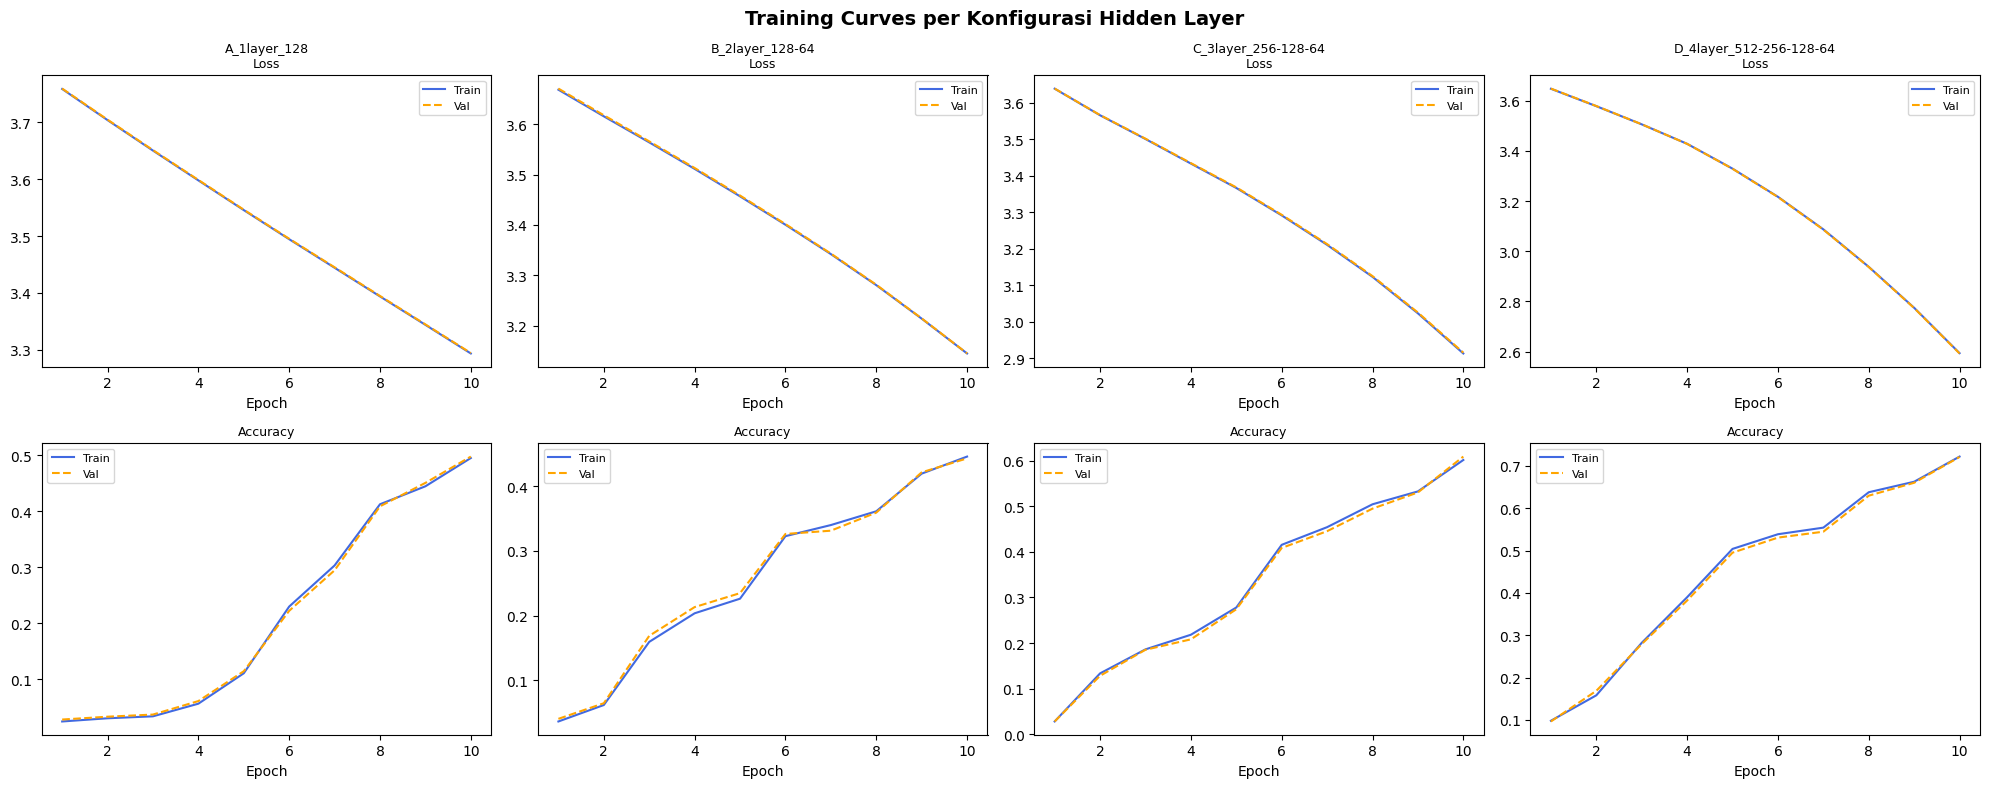

In [ ]:
# Plot training loss dan accuracy untuk setiap eksperimen
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Training Curves per Konfigurasi Hidden Layer', fontsize=14, fontweight='bold')

colors = ['royalblue', 'orange']

for idx, (name, res) in enumerate(results.items()):
    mlp = res['model']
    ax_loss = axes[0, idx]
    ax_acc  = axes[1, idx]

    epochs_ran = range(1, len(mlp.train_losses) + 1)

    ax_loss.plot(epochs_ran, mlp.train_losses, label='Train', color=colors[0])
    if mlp.val_losses:
        ax_loss.plot(epochs_ran, mlp.val_losses, label='Val', color=colors[1], linestyle='--')
    ax_loss.set_title(f'{name}\nLoss', fontsize=9)
    ax_loss.legend(fontsize=8)
    ax_loss.set_xlabel('Epoch')

    ax_acc.plot(epochs_ran, mlp.train_accs, label='Train', color=colors[0])
    if mlp.val_accs:
        ax_acc.plot(epochs_ran, mlp.val_accs, label='Val', color=colors[1], linestyle='--')
    ax_acc.set_title(f'Accuracy', fontsize=9)
    ax_acc.legend(fontsize=8)
    ax_acc.set_xlabel('Epoch')

plt.tight_layout()
plt.show()

Visualisasi Training & Perbandingan Arsitektur

Perbandingan Konfigurasi Hidden Layer Berdasarkan Validation Set


,Eksperimen,Val Accuracy,Val Precision,Val Recall,Val F1-Score
0,D_4layer_512-256-128-64,0.720812,0.620677,0.720812,0.648222
1,C_3layer_256-128-64,0.609137,0.499233,0.609137,0.522821
2,A_1layer_128,0.497462,0.422186,0.497462,0.411170
3,B_2layer_128-64,0.442893,0.392222,0.442893,0.360320


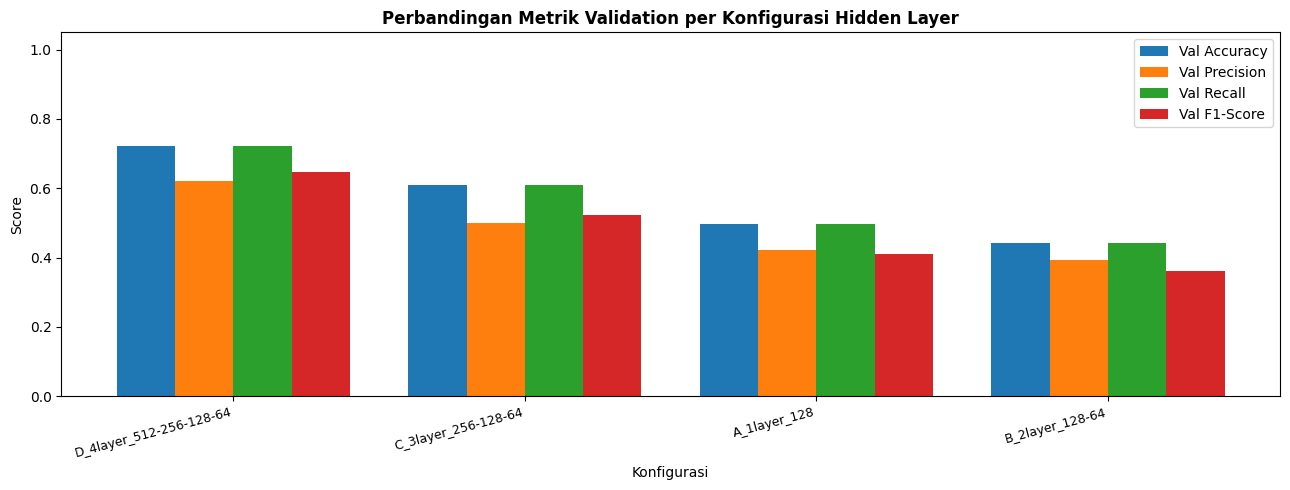


Konfigurasi terbaik berdasarkan Validation F1-Score: D_4layer_512-256-128-64
Arsitektur terbaik: [131, 512, 256, 128, 64, 41]
Validation F1-Score terbaik: 0.6482
Validation Accuracy terbaik: 0.7208


In [ ]:
# Tabel perbandingan semua eksperimen hidden layer
# Semua metrik di sini berasal dari validation set.

summary_data = {
    'Eksperimen': list(results.keys()),
    'Val Accuracy':  [results[k]['val_accuracy']  for k in results],
    'Val Precision': [results[k]['val_precision'] for k in results],
    'Val Recall':    [results[k]['val_recall']    for k in results],
    'Val F1-Score':  [results[k]['val_f1']        for k in results],
}

df_summary = pd.DataFrame(summary_data)

# Konfigurasi terbaik ditentukan berdasarkan Validation F1-Score
df_summary = df_summary.sort_values('Val F1-Score', ascending=False).reset_index(drop=True)

print("Perbandingan Konfigurasi Hidden Layer Berdasarkan Validation Set")
display(df_summary)

# Visualisasi perbandingan
metrics = ['Val Accuracy', 'Val Precision', 'Val Recall', 'Val F1-Score']
x = np.arange(len(df_summary))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 5))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, df_summary[metric], width, label=metric)

ax.set_xlabel('Konfigurasi')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik Validation per Konfigurasi Hidden Layer', fontweight='bold')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(df_summary['Eksperimen'], rotation=15, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

best_name = df_summary.iloc[0]['Eksperimen']
best_architecture = results[best_name]['architecture']

print(f"\nKonfigurasi terbaik berdasarkan Validation F1-Score: {best_name}")
print(f"Arsitektur terbaik: {best_architecture}")
print(f"Validation F1-Score terbaik: {df_summary.iloc[0]['Val F1-Score']:.4f}")
print(f"Validation Accuracy terbaik: {df_summary.iloc[0]['Val Accuracy']:.4f}")

In [ ]:
# Eksperimen Perbandingan Fungsi Aktivasi
# Menggunakan arsitektur terbaik dari eksperimen hidden layer
# Evaluasi tetap menggunakan validation set.

activation_functions = ['relu', 'sigmoid', 'tanh']

print("Arsitektur terbaik yang digunakan untuk eksperimen fungsi aktivasi:")
print(f"Nama konfigurasi : {best_name}")
print(f"Arsitektur       : {best_architecture}")

activation_results = {}

for activation_name in activation_functions:
    print(f"Eksperimen Fungsi Aktivasi: {activation_name.upper()}")
    print(f"Arsitektur: {best_architecture}")

    np.random.seed(42)

    mlp = MLPClassifier(
        layer_sizes=best_architecture,
        learning_rate=0.01,
        epochs=10,
        batch_size=64,
        dropout_rate=0.3,
        patience=5,
        activation=activation_name,
        verbose=True
    )

    # Validation set dipakai untuk early stopping
    mlp.fit(X_train_w, y_train, X_val=X_val_w, y_val=y_val)

    # Evaluasi model pada validation set
    y_val_pred = mlp.predict(X_val_w)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_prec = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_rec = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

    activation_results[activation_name] = {
        'model': mlp,
        'val_accuracy': val_acc,
        'val_precision': val_prec,
        'val_recall': val_rec,
        'val_f1': val_f1,
        'architecture': best_architecture
    }

    print(f"\n>> Hasil Validation Aktivasi {activation_name.upper()}:")
    print(f"Val Accuracy : {val_acc:.4f}")
    print(f"Val Precision: {val_prec:.4f}")
    print(f"Val Recall   : {val_rec:.4f}")
    print(f"Val F1-Score : {val_f1:.4f}")
    print()

Arsitektur terbaik yang digunakan untuk eksperimen fungsi aktivasi:
Nama konfigurasi : D_4layer_512-256-128-64
Arsitektur       : [131, 512, 256, 128, 64, 41]
Eksperimen Fungsi Aktivasi: RELU
Arsitektur: [131, 512, 256, 128, 64, 41]
Epoch   10 | Train Loss: 2.5940 | Train Acc: 0.7217 | Val Loss: 2.5928 | Val Acc: 0.7208

>> Hasil Validation Aktivasi RELU:
Val Accuracy : 0.7208
Val Precision: 0.6207
Val Recall   : 0.7208
Val F1-Score : 0.6482

Eksperimen Fungsi Aktivasi: SIGMOID
Arsitektur: [131, 512, 256, 128, 64, 41]
Epoch   10 | Train Loss: 3.7153 | Train Acc: 0.0245 | Val Loss: 3.7154 | Val Acc: 0.0241

>> Hasil Validation Aktivasi SIGMOID:
Val Accuracy : 0.0241
Val Precision: 0.0006
Val Recall   : 0.0241
Val F1-Score : 0.0012

Eksperimen Fungsi Aktivasi: TANH
Arsitektur: [131, 512, 256, 128, 64, 41]
Epoch   10 | Train Loss: 1.9787 | Train Acc: 0.9219 | Val Loss: 1.9795 | Val Acc: 0.9251

>> Hasil Validation Aktivasi TANH:
Val Accuracy : 0.9251
Val Precision: 0.9083
Val Recall   : 0

In [ ]:
# Tabel Perbandingan Fungsi Aktivasi
# Semua metrik di sini berasal dari validation set.

activation_comparison = pd.DataFrame({
    name.upper(): {
        'Val Accuracy': result['val_accuracy'],
        'Val Precision': result['val_precision'],
        'Val Recall': result['val_recall'],
        'Val F1-Score': result['val_f1']
    }
    for name, result in activation_results.items()
}).T

activation_comparison = activation_comparison.sort_values(
    by='Val F1-Score',
    ascending=False
)

print("Perbandingan Fungsi Aktivasi pada MLP Berdasarkan Validation Set")
display(activation_comparison)

best_activation = activation_comparison.index[0]
best_activation_key = best_activation.lower()
best_model = activation_results[best_activation_key]['model']

print(f"\nFungsi aktivasi terbaik berdasarkan Validation F1-Score: {best_activation}")
print(f"Validation F1-Score terbaik: {activation_comparison.loc[best_activation, 'Val F1-Score']:.4f}")
print(f"Validation Accuracy terbaik: {activation_comparison.loc[best_activation, 'Val Accuracy']:.4f}")

Perbandingan Fungsi Aktivasi pada MLP Berdasarkan Validation Set


,Val Accuracy,Val Precision,Val Recall,Val F1-Score
TANH,0.925127,0.908297,0.925127,0.905525
RELU,0.720812,0.620677,0.720812,0.648222
SIGMOID,0.024112,0.000608,0.024112,0.001187



Fungsi aktivasi terbaik berdasarkan Validation F1-Score: TANH
Validation F1-Score terbaik: 0.9055
Validation Accuracy terbaik: 0.9251


In [ ]:
# Evaluasi Final pada Test Set
# Test set hanya digunakan sekali setelah arsitektur dan aktivasi terbaik dipilih.

print("Evaluasi Final pada Test Set")
print(f"Arsitektur terbaik : {best_architecture}")
print(f"Aktivasi terbaik   : {best_activation}")

y_test_pred = best_model.predict(X_test_w)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_rec = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

final_test_result = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Test Score': [test_acc, test_prec, test_rec, test_f1]
})

display(final_test_result)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall   : {test_rec:.4f}")
print(f"Test F1-Score : {test_f1:.4f}")

Evaluasi Final pada Test Set
Arsitektur terbaik : [131, 512, 256, 128, 64, 41]
Aktivasi terbaik   : TANH


,Metric,Test Score
0,Accuracy,0.919715
1,Precision,0.901392
2,Recall,0.919715
3,F1-Score,0.896159


Test Accuracy : 0.9197
Test Precision: 0.9014
Test Recall   : 0.9197
Test F1-Score : 0.8962


# Perbandingan Sebelum dan Sesudah Proses Backpropagation

Bagian ini digunakan untuk melihat perubahan performa model sebelum dan sesudah proses training menggunakan backpropagation.

Pada tahap sebelum backpropagation, model hanya menggunakan bobot awal hasil inisialisasi random. Artinya, model belum belajar pola hubungan antara gejala dan penyakit.

Pada tahap sesudah backpropagation, bobot model sudah diperbarui melalui proses forward propagation, perhitungan loss, backward propagation, dan update parameter. Dengan demikian, model diharapkan mampu menghasilkan prediksi yang lebih akurat.

In [ ]:
# Perbandingan Sebelum dan Sesudah Backpropagation

print("Perbandingan Sebelum dan Sesudah Backpropagation")
print(f"Arsitektur yang digunakan : {best_architecture}")
print(f"Aktivasi yang digunakan   : {best_activation_key}")

# A. Model sebelum backpropagation

# Model dibuat dengan arsitektur dan aktivasi terbaik,
# tetapi tidak dilatih menggunakan fit().
# Dengan demikian, bobot masih berupa hasil inisialisasi awal.

np.random.seed(42)

model_before_bp = MLPClassifier(
    layer_sizes=best_architecture,
    learning_rate=0.01,
    epochs=15,
    batch_size=64,
    dropout_rate=0.3,
    patience=5,
    activation=best_activation_key,
    verbose=False
)


y_pred_before_bp = model_before_bp.predict(X_test_w)

before_acc = accuracy_score(y_test, y_pred_before_bp)
before_prec = precision_score(y_test, y_pred_before_bp, average='weighted', zero_division=0)
before_rec = recall_score(y_test, y_pred_before_bp, average='weighted', zero_division=0)
before_f1 = f1_score(y_test, y_pred_before_bp, average='weighted', zero_division=0)


# B. Model sesudah backpropagation
# best_model adalah model yang sudah dilatih menggunakan fit(),
# sehingga bobotnya sudah diperbarui melalui backpropagation.

y_pred_after_bp = best_model.predict(X_test_w)

after_acc = accuracy_score(y_test, y_pred_after_bp)
after_prec = precision_score(y_test, y_pred_after_bp, average='weighted', zero_division=0)
after_rec = recall_score(y_test, y_pred_after_bp, average='weighted', zero_division=0)
after_f1 = f1_score(y_test, y_pred_after_bp, average='weighted', zero_division=0)


# C. Tabel perbandingan
bp_comparison = pd.DataFrame({
    'Kondisi Model': [
        'Sebelum Backpropagation',
        'Sesudah Backpropagation'
    ],
    'Accuracy': [
        before_acc,
        after_acc
    ],
    'Precision': [
        before_prec,
        after_prec
    ],
    'Recall': [
        before_rec,
        after_rec
    ],
    'F1-Score': [
        before_f1,
        after_f1
    ]
})

display(bp_comparison)

print("\nRingkasan:")
print(f"Accuracy sebelum backpropagation : {before_acc:.4f}")
print(f"Accuracy sesudah backpropagation : {after_acc:.4f}")
print(f"F1-score sebelum backpropagation : {before_f1:.4f}")
print(f"F1-score sesudah backpropagation : {after_f1:.4f}")

Perbandingan Sebelum dan Sesudah Backpropagation
Arsitektur yang digunakan : [131, 512, 256, 128, 64, 41]
Aktivasi yang digunakan   : tanh


,Kondisi Model,Accuracy,Precision,Recall,F1-Score
0,Sebelum Backpropagation,0.045732,0.013209,0.045732,0.019534
1,Sesudah Backpropagation,0.919715,0.901392,0.919715,0.896159



Ringkasan:
Accuracy sebelum backpropagation : 0.0457
Accuracy sesudah backpropagation : 0.9197
F1-score sebelum backpropagation : 0.0195
F1-score sesudah backpropagation : 0.8962


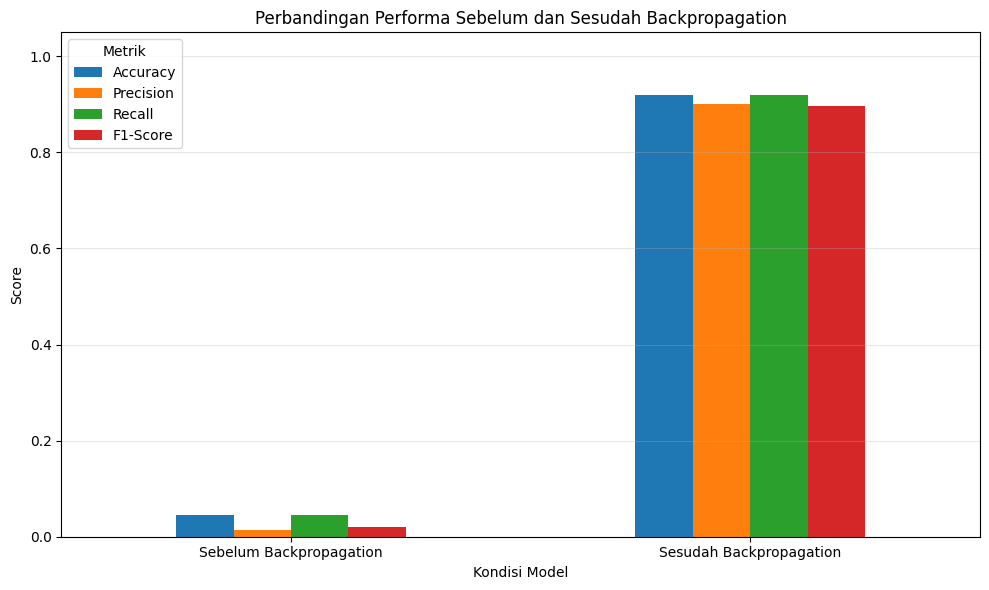

In [ ]:
# Visualisasi Perbandingan Sebelum dan Sesudah Backpropagation

plot_bp = bp_comparison.set_index('Kondisi Model')

ax = plot_bp.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Perbandingan Performa Sebelum dan Sesudah Backpropagation')
plt.xlabel('Kondisi Model')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Metrik')
plt.tight_layout()
plt.show()

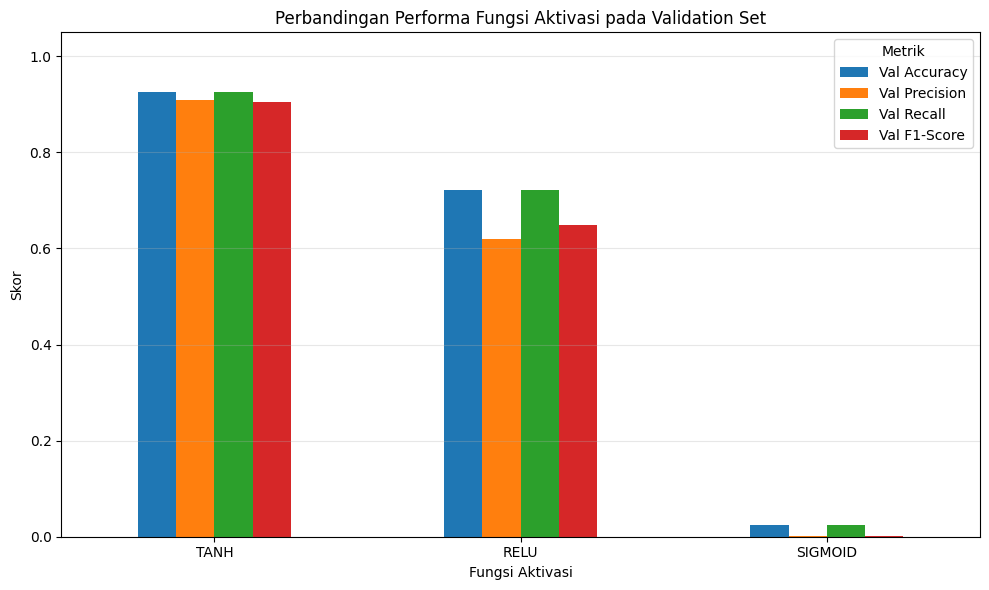

In [ ]:
# Visualisasi Perbandingan Fungsi Aktivasi Berdasarkan Validation Set

ax = activation_comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Perbandingan Performa Fungsi Aktivasi pada Validation Set')
plt.xlabel('Fungsi Aktivasi')
plt.ylabel('Skor')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Metrik')
plt.tight_layout()
plt.show()

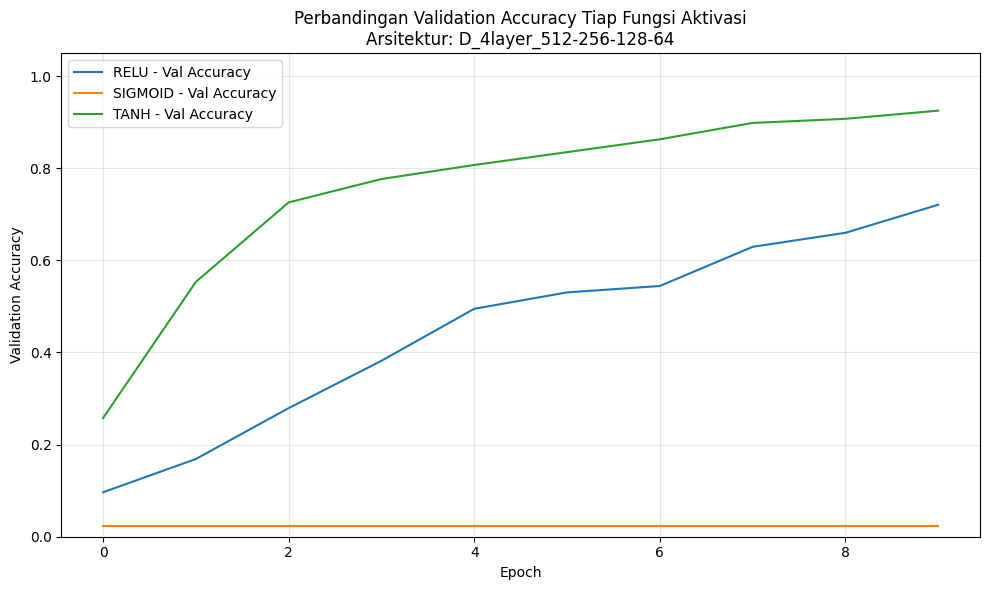

In [ ]:
# Visualisasi Validation Accuracy untuk Setiap Fungsi Aktivasi

plt.figure(figsize=(10, 6))

for activation_name, result in activation_results.items():
    model = result['model']
    plt.plot(
        model.val_accs,
        label=f'{activation_name.upper()} - Val Accuracy'
    )

plt.title(f'Perbandingan Validation Accuracy Tiap Fungsi Aktivasi\nArsitektur: {best_name}')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

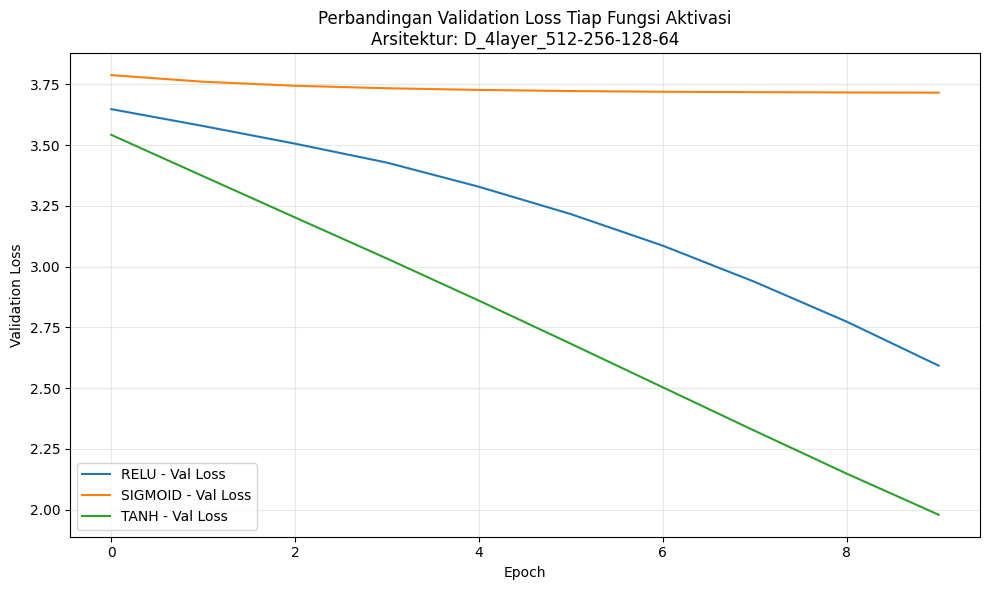

In [ ]:
# Visualisasi Validation Loss untuk Setiap Fungsi Aktivasi

plt.figure(figsize=(10, 6))

for activation_name, result in activation_results.items():
    model = result['model']
    plt.plot(
        model.val_losses,
        label=f'{activation_name.upper()} - Val Loss'
    )

plt.title(f'Perbandingan Validation Loss Tiap Fungsi Aktivasi\nArsitektur: {best_name}')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Progress Terakhir

# Evaluasi Detail Model Final

Setelah arsitektur dan fungsi aktivasi terbaik dipilih menggunakan validation set, model terbaik dievaluasi lebih dalam menggunakan test set.

Evaluasi ini mencakup:
1. Classification report
2. Confusion matrix
3. Analisis kesalahan prediksi
4. Perbandingan severity weighted vs binary input
5. Baseline model pembanding
6. Fungsi prediksi penyakit dari input gejala

In [ ]:
# Classification Report dalam Bentuk DataFrame

report_dict = classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_,
    zero_division=0,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).T

display(df_report)

,precision,recall,f1-score,support
(vertigo) Paroymsal Positional Vertigo,0.960000,1.000000,0.979592,24.000000
AIDS,0.923077,1.000000,0.960000,24.000000
Acne,0.000000,0.000000,0.000000,24.000000
Alcoholic hepatitis,1.000000,1.000000,1.000000,24.000000
Allergy,1.000000,1.000000,1.000000,24.000000
Arthritis,1.000000,1.000000,1.000000,24.000000
Bronchial Asthma,1.000000,1.000000,1.000000,24.000000
Cervical spondylosis,1.000000,1.000000,1.000000,24.000000
Chicken pox,1.000000,1.000000,1.000000,24.000000
Chronic cholestasis,0.000000,0.000000,0.000000,24.000000


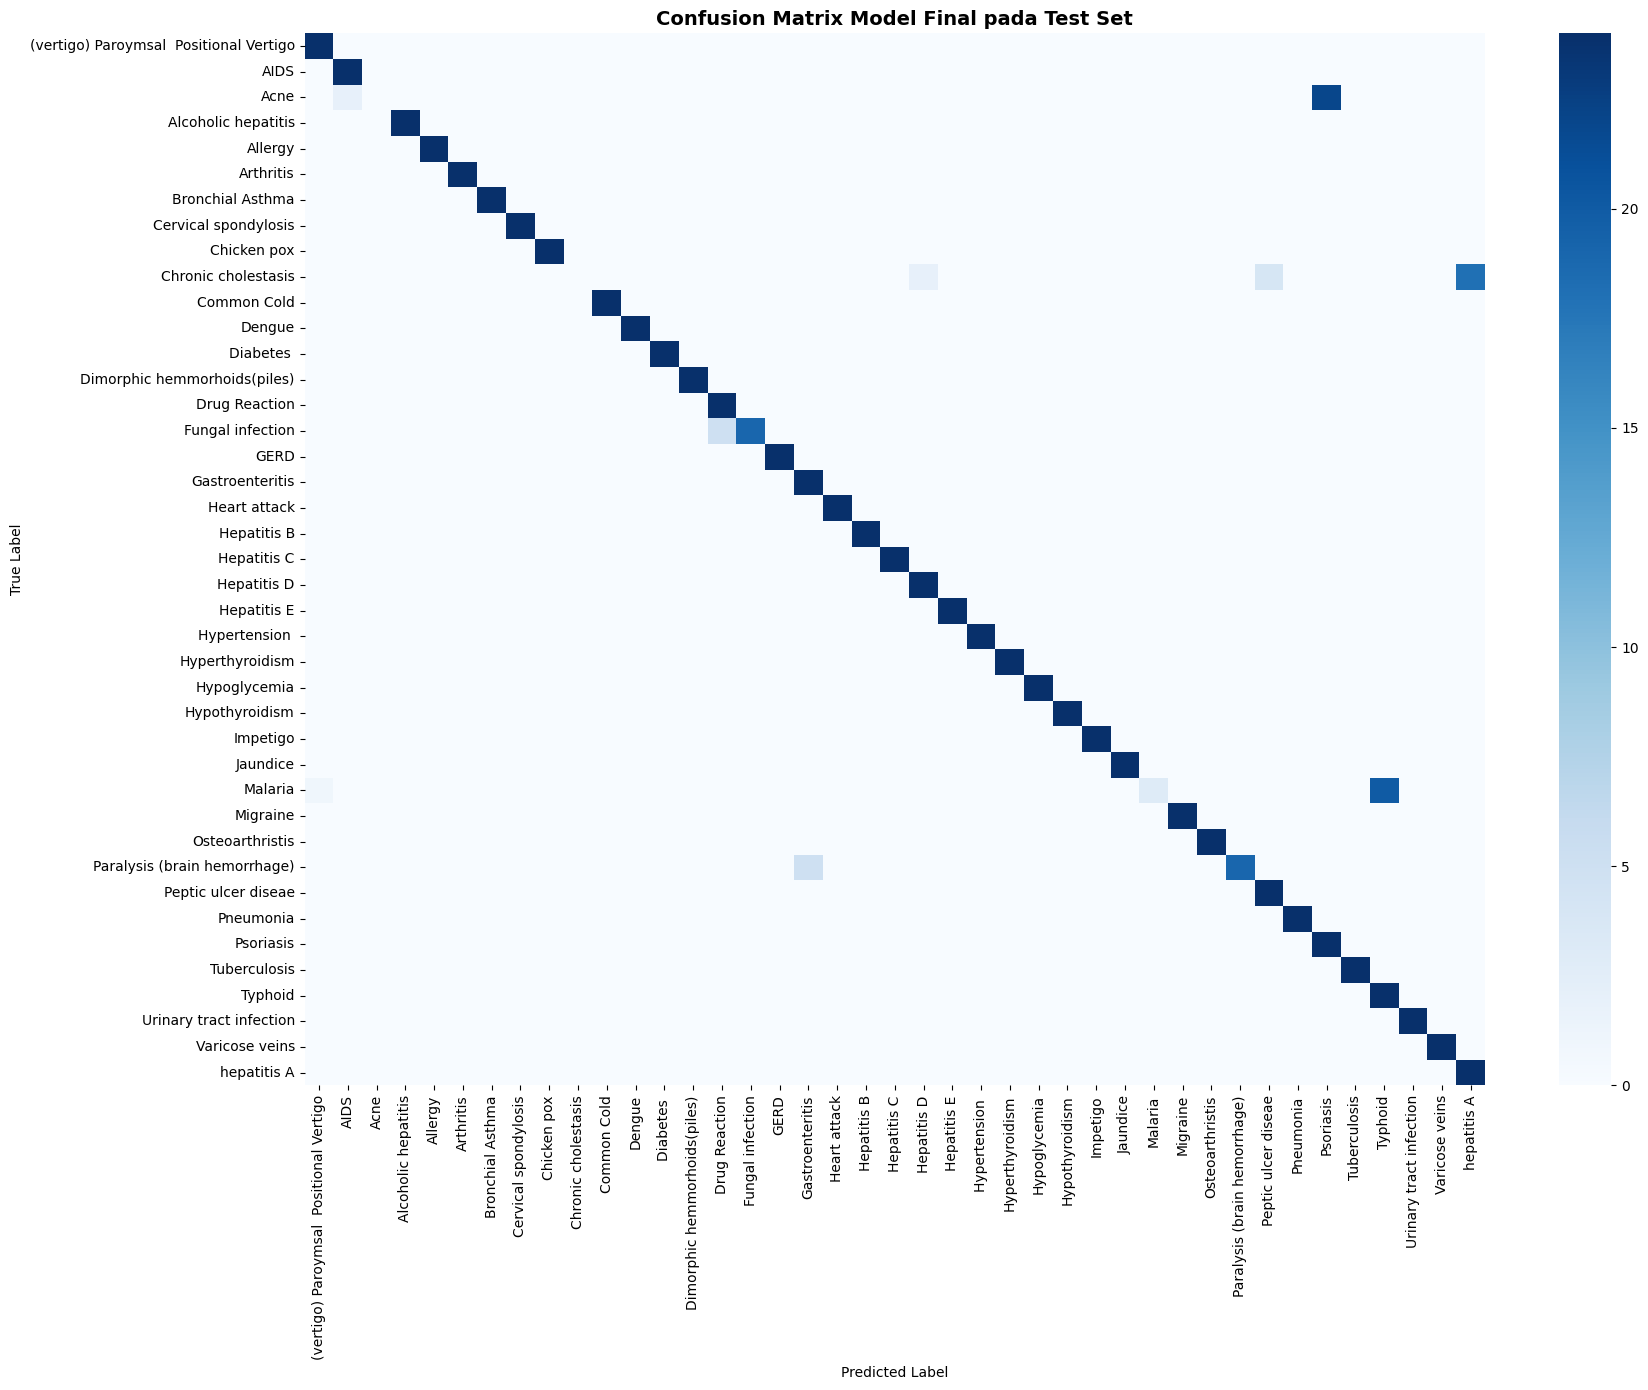

In [ ]:
# Confusion Matrix Model Final

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(18, 14))
sns.heatmap(
    cm,
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    annot=False
)

plt.title('Confusion Matrix Model Final pada Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Analisis Kesalahan Prediksi

wrong_indices = np.where(y_test != y_test_pred)[0]

print(f"Jumlah prediksi salah: {len(wrong_indices)} dari {len(y_test)} data test")
print(f"Persentase kesalahan : {len(wrong_indices) / len(y_test) * 100:.2f}%")

error_analysis = []

for idx in wrong_indices:
    true_label = le.inverse_transform([y_test[idx]])[0]
    pred_label = le.inverse_transform([y_test_pred[idx]])[0]

    error_analysis.append({
        'Index Test': idx,
        'Actual Disease': true_label,
        'Predicted Disease': pred_label
    })

df_errors = pd.DataFrame(error_analysis)

display(df_errors.head(20))

Jumlah prediksi salah: 79 dari 984 data test
Persentase kesalahan : 8.03%


,Index Test,Actual Disease,Predicted Disease
0,19,Fungal infection,Drug Reaction
1,74,Paralysis (brain hemorrhage),Gastroenteritis
2,75,Acne,Psoriasis
3,93,Acne,Psoriasis
4,126,Acne,AIDS
5,127,Acne,Psoriasis
6,131,Malaria,Typhoid
7,167,Malaria,Typhoid
8,222,Malaria,Typhoid
9,245,Acne,Psoriasis


In [ ]:
# Ringkasan Penyakit yang Paling Sering Salah Diprediksi

if len(df_errors) > 0:
    error_summary = (
        df_errors
        .groupby(['Actual Disease', 'Predicted Disease'])
        .size()
        .reset_index(name='Jumlah Kesalahan')
        .sort_values('Jumlah Kesalahan', ascending=False)
    )

    display(error_summary.head(20))
else:
    print("Tidak ada kesalahan prediksi pada test set.")

,Actual Disease,Predicted Disease,Jumlah Kesalahan
1,Acne,Psoriasis,22
7,Malaria,Typhoid,20
4,Chronic cholestasis,hepatitis A,18
8,Paralysis (brain hemorrhage),Gastroenteritis,5
5,Fungal infection,Drug Reaction,5
3,Chronic cholestasis,Peptic ulcer diseae,4
0,Acne,AIDS,2
2,Chronic cholestasis,Hepatitis D,2
6,Malaria,(vertigo) Paroymsal Positional Vertigo,1


# Perbandingan Severity Weighted Input vs Binary Input

Bagian ini membandingkan apakah penggunaan bobot severity benar-benar meningkatkan performa model dibandingkan input binary biasa.

Dua model dilatih menggunakan arsitektur dan fungsi aktivasi terbaik yang sama:
1. Model dengan severity weighted input
2. Model dengan binary input

Perbandingan dilakukan menggunakan validation set dan test set.

In [ ]:
# Training Model Binary sebagai Pembanding Severity Weighted

print("Training model dengan input binary sebagai pembanding...")
print(f"Arsitektur yang digunakan: {best_architecture}")
print(f"Aktivasi yang digunakan  : {best_activation_key}")

np.random.seed(42)

binary_model = MLPClassifier(
    layer_sizes=best_architecture,
    learning_rate=0.01,
    epochs=10,
    batch_size=64,
    dropout_rate=0.3,
    patience=5,
    activation=best_activation_key,
    verbose=True
)

binary_model.fit(
    X_train_b,
    y_train,
    X_val=X_val_b,
    y_val=y_val
)

y_val_pred_binary = binary_model.predict(X_val_b)
y_test_pred_binary = binary_model.predict(X_test_b)

binary_val_acc = accuracy_score(y_val, y_val_pred_binary)
binary_val_prec = precision_score(y_val, y_val_pred_binary, average='weighted', zero_division=0)
binary_val_rec = recall_score(y_val, y_val_pred_binary, average='weighted', zero_division=0)
binary_val_f1 = f1_score(y_val, y_val_pred_binary, average='weighted', zero_division=0)

binary_test_acc = accuracy_score(y_test, y_test_pred_binary)
binary_test_prec = precision_score(y_test, y_test_pred_binary, average='weighted', zero_division=0)
binary_test_rec = recall_score(y_test, y_test_pred_binary, average='weighted', zero_division=0)
binary_test_f1 = f1_score(y_test, y_test_pred_binary, average='weighted', zero_division=0)

print("\nTraining model binary selesai.")

Training model dengan input binary sebagai pembanding...
Arsitektur yang digunakan: [131, 512, 256, 128, 64, 41]
Aktivasi yang digunakan  : tanh
Epoch   10 | Train Loss: 1.2339 | Train Acc: 0.9952 | Val Loss: 1.2374 | Val Acc: 0.9987

Training model binary selesai.


In [ ]:
# Perbandingan Severity Weighted vs Binary Input

weighted_vs_binary = pd.DataFrame({
    'Input Type': ['Severity Weighted', 'Binary'],
    'Val Accuracy': [
        activation_results[best_activation_key]['val_accuracy'],
        binary_val_acc
    ],
    'Val Precision': [
        activation_results[best_activation_key]['val_precision'],
        binary_val_prec
    ],
    'Val Recall': [
        activation_results[best_activation_key]['val_recall'],
        binary_val_rec
    ],
    'Val F1-Score': [
        activation_results[best_activation_key]['val_f1'],
        binary_val_f1
    ],
    'Test Accuracy': [
        test_acc,
        binary_test_acc
    ],
    'Test Precision': [
        test_prec,
        binary_test_prec
    ],
    'Test Recall': [
        test_rec,
        binary_test_rec
    ],
    'Test F1-Score': [
        test_f1,
        binary_test_f1
    ]
})

display(weighted_vs_binary)

,Input Type,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,Severity Weighted,0.925127,0.908297,0.925127,0.905525,0.919715,0.901392,0.919715,0.896159
1,Binary,0.998731,0.998794,0.998731,0.998730,0.997967,0.998124,0.997967,0.997964


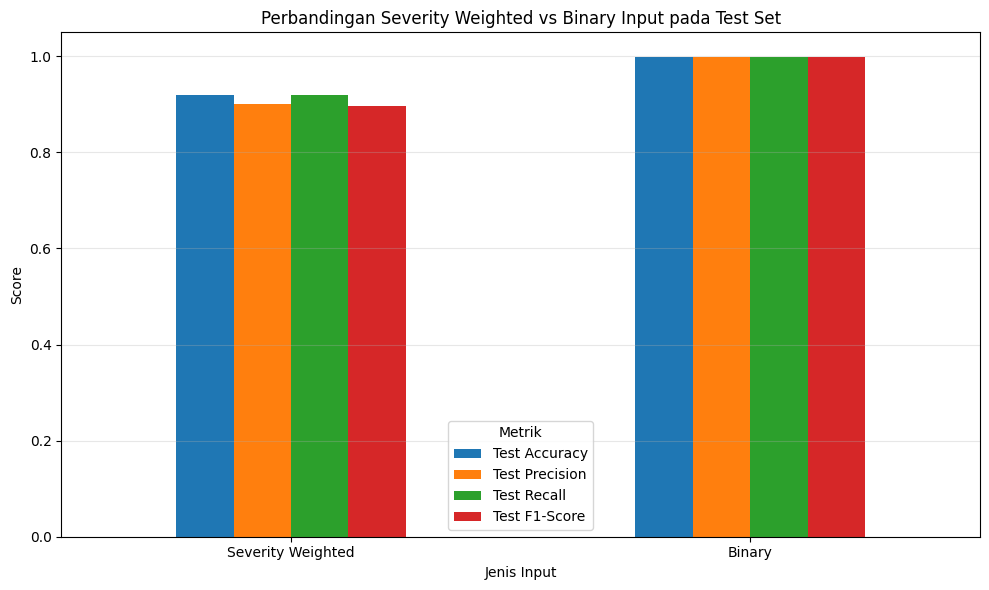

In [ ]:
# Visualisasi Perbandingan Severity Weighted vs Binary Input pada Test Set

plot_data = weighted_vs_binary.set_index('Input Type')[
    ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score']
]

ax = plot_data.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Perbandingan Severity Weighted vs Binary Input pada Test Set')
plt.xlabel('Jenis Input')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Metrik')
plt.tight_layout()
plt.show()

# Fungsi Prediksi Penyakit dari Input Gejala

Bagian ini digunakan untuk melakukan simulasi diagnosis berdasarkan daftar gejala yang dimasukkan secara manual.

Model akan mengubah daftar gejala menjadi vektor input, lalu menghasilkan beberapa prediksi penyakit dengan probabilitas tertinggi.

In [ ]:
# Fungsi Prediksi Penyakit dari Input Gejala Manual

def predict_disease_from_symptoms(symptoms, model=best_model, top_k=5, use_severity=True):
    """
    Melakukan prediksi penyakit berdasarkan daftar gejala.

    Parameters:
    symptoms : list
        Daftar gejala dalam bentuk string.
    model : MLPClassifier
        Model MLP yang sudah dilatih.
    top_k : int
        Jumlah prediksi teratas yang ingin ditampilkan.
    use_severity : bool
        Jika True, gunakan bobot severity.
        Jika False, gunakan binary input.

    Returns:
    DataFrame berisi top-k prediksi penyakit.
    """

    input_vector = np.zeros(len(all_unique_symptoms))
    unknown_symptoms = []

    for symptom in symptoms:
        cleaned_symptom = clean_symptom_name(symptom)

        if cleaned_symptom in symptom_index:
            idx = symptom_index[cleaned_symptom]

            if use_severity:
                input_vector[idx] = severity_weights[idx] / max_severity
            else:
                input_vector[idx] = 1
        else:
            unknown_symptoms.append(symptom)

    input_vector = input_vector.reshape(1, -1)

    probabilities = model.predict_proba(input_vector)[0]
    top_indices = np.argsort(probabilities)[::-1][:top_k]

    results = []

    for idx in top_indices:
        results.append({
            'Disease': le.inverse_transform([idx])[0],
            'Probability': probabilities[idx]
        })

    df_prediction = pd.DataFrame(results)

    if len(unknown_symptoms) > 0:
        print("Gejala berikut tidak ditemukan dalam daftar gejala dataset:")
        for symptom in unknown_symptoms:
            print(f"- {symptom}")

    return df_prediction

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

selected_symptoms = []

dropdown = widgets.Dropdown(
    options=sorted(all_unique_symptoms),
    description='Gejala:'
)

add_button = widgets.Button(
    description='Tambah Gejala',
    button_style='info'
)

predict_button = widgets.Button(
    description='Prediksi',
    button_style='success'
)

symptom_output = widgets.Output()
prediction_output = widgets.Output()

def add_symptom(btn):
    symptom = dropdown.value

    if symptom not in selected_symptoms:
        selected_symptoms.append(symptom)

    with symptom_output:
        clear_output()

        print("Gejala yang dipilih:")

        for s in selected_symptoms:
            print(f"• {s}")

def predict(btn):
    with prediction_output:
        clear_output()

        if len(selected_symptoms) == 0:
            print("Tambahkan minimal satu gejala.")
            return

        result = predict_disease_from_symptoms(
            selected_symptoms,
            model=best_model,
            top_k=5,
            use_severity=True
        )

        display(result)

add_button.on_click(add_symptom)
predict_button.on_click(predict)

display(
    widgets.VBox([
        dropdown,
        add_button,
        symptom_output,
        predict_button,
        prediction_output
    ])
)